## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kevin Sun

**Date:** 10/3/2026

In [40]:
# Your Phase 1 solution to the problem goes here.


**Q1.**
1. What is the difference between regression and classification?

    The difference between regression and classification is that regression predicts a numeric outcome while classification predicts a category/class label.

2. What is a confusion table? What does it help us understand about a model's performance?

    A confusion table/matrix counts predictions by actual class and predicted class. This helps us understand a model's performance because it shows us which observations were classified correctly and which observations were classified incorrectly. The table also includes the types of errors the model made.


3. What does the SSE quantify about a particular model?

    The SSE quantifies the total squared difference between the model's predictions and the actual values. A lower validation SSE means that the model's predictions have smaller errors on the data being evaluated.

4. What are overfitting and underfitting? 

    Overfitting is when a model is too complex and learns the training data too closely, almost sort of "memorizing" the training data. As a result, the model will include patterns that do not generalize to new data. Underfitting is when a model is too simple to identify important patterns in the data. Overfit models generally perform well on the training data but bad on new data, while underfit models generally just perform bad on both training and new data.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

    Splitting the data allows for us to train the model on one set of observations and evaluate how well it performs on data that it has not seen before. This improves model performance because it helps us determine how well the model generalizes to new data rather than only measuring how well it fits the training data. Choosing K by evaluating SSE on the test set (on a graph) allows us to see how the model's error changes as K changes and choose a K value that gives a relatively low SSE. This improves model performance because it helps us avoid choosing a K value that causes the model to overfit or underfit the data.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

    Reporting a class label gives us a simple/easily understandable prediction to interpret and is useful when making a direct decision about which class an observation belongs to. However, it does not tell us how confident the model is at making these decisions. Reporting a probability distribution provides more information by showing the model's estimated probability for each class. However, probabilities can be more difficult to understand/comprehend and may not always be super accurate. 

In [41]:
%pip install pandas
%pip install matplotlib seaborn scipy
%pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [42]:
df = pd.read_csv('/workspaces/A03-knn/data/land_mines.csv')

In [43]:
print(df.shape, '\n')
print(df.info(), '\n')

print(df.describe(), '\n')

print(df.isnull().sum(), '\n')

print(df['mine_type'].value_counts(),'\n')

print(df[['voltage']].describe(),'\n')

print(df[['height']].describe(),'\n')

print(df[['soil']].describe(),'\n')

(338, 4) 

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None 

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

mine_type
1    71
2    70
3    66
4

<Axes: xlabel='mine_type'>

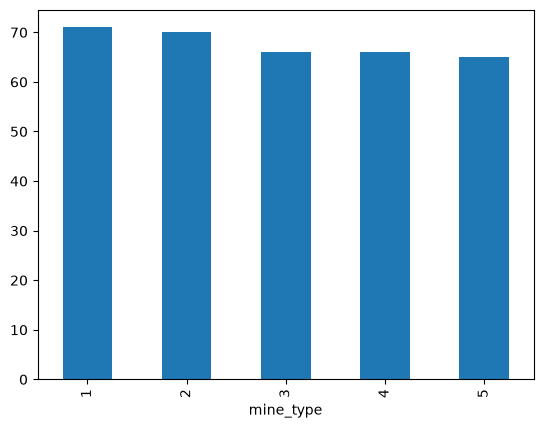

In [44]:
df['mine_type'].value_counts().plot(kind='bar')

array([[<Axes: title={'center': 'voltage'}>]], dtype=object)

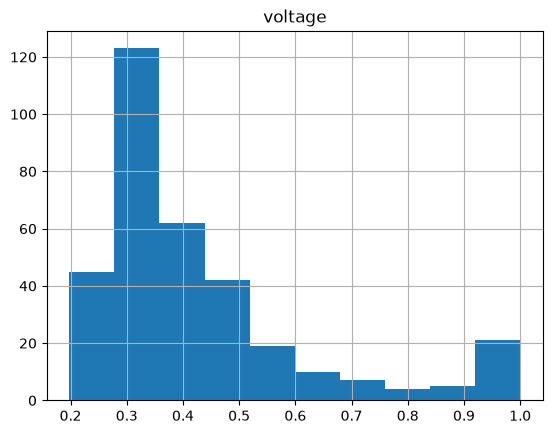

In [45]:
df[['voltage']].hist()

array([[<Axes: title={'center': 'height'}>]], dtype=object)

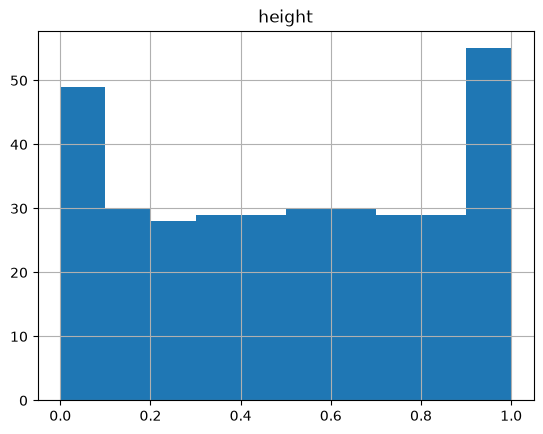

In [46]:
df[['height']].hist()

array([[<Axes: title={'center': 'soil'}>]], dtype=object)

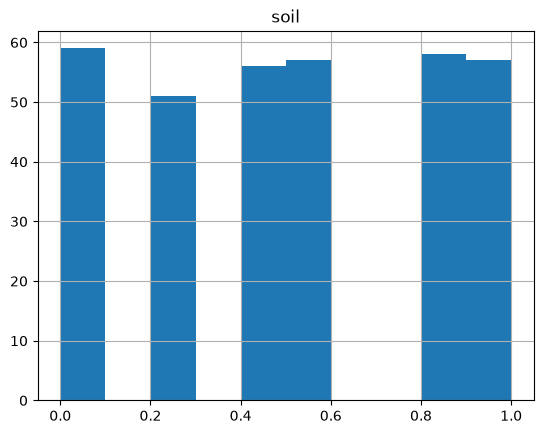

In [47]:
df[['soil']].hist()

Q2.1

This dataset contains 338 observations and four variables: voltage, height, soil, and mine_type, with mine_type being the target variable. There are no missing values in the dataset. The target contains five mine types, with 71 observations of type 1, 70 of type 2, 66 of type 3, 66 of type 4, and 65 of type 5 (so it's relatively balanced). The mean values of voltage, height, and soil are 0.431, 0.509, 
and 0.504, respectively. The features range from approximately 0 to 1 (so they are already on similar scales). This is good for knn because knn relies on distances between observations.

In [48]:
# Q2.2

X = df[['voltage', 'height', 'soil']]
Y = df['mine_type']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.5, random_state=65
)

In [49]:
# Q2.3

eval_ks = np.arange(1, 51)
eval_valid_accuracy = []
eval_train_accuracy = []

for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(X_train, Y_train)
    
    eval_valid_hat = eval_candidate.predict(X_test)
    eval_train_hat = eval_candidate.predict(X_train)
    
    eval_valid_accuracy.append(
        np.mean(Y_test.to_numpy() == eval_valid_hat)
    )
    
    eval_train_accuracy.append(
        np.mean(Y_train.to_numpy() == eval_train_hat)
    )

eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)])

In [50]:
print(eval_k_star)

11


I tested values of K from 1-50 and chose the value of K that produced the highest validation accuracy which was K=11

In [51]:
eval_candidate = KNeighborsClassifier(n_neighbors=eval_k_star)
eval_candidate.fit(X_train, Y_train)

eval_test_hat = eval_candidate.predict(X_test)

confusion = confusion_matrix(Y_test, eval_test_hat)

print(confusion)

[[23  0  5  1  5]
 [ 0 30  6  0  2]
 [ 3  3 11  1 12]
 [13  1 12  5  7]
 [12  0 10  2  5]]


This model's performance varies greatly. Performance was highest for mine type 2 and was also pretty good for mine type 1, while performance was lowest for mine types 4 and 5. The model struggled to distinguish between types 3, 4, and 5, with several observations from these classes being classified as one of the other types. Overall, the model doesn't seem to be that great at classifying mine types.

Q2.5

Given the model's overall low accuracy, I would not recommend using it as the sole method for identifying land mines, as an incorrect classification could result in dangerous consequences. Instead, the model could be used as a sort of tool to provide an initial prediction, while trained personnel can make the final decision. This would allow the model to be useful and safe to use at the same time.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [52]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]